1. Library Import and Environment Setup

This study aims to develop a machine learning framework for predicting tsunami occurrence using earthquake parameters. The following libraries are imported to support data handling, visualization, model development, cross-validation, and class imbalance treatment.

Stratified cross-validation is used to ensure balanced distribution of rare tsunami events across folds. SMOTE is included to handle class imbalance during training.

In [203]:
# =========================================
# 1. Import Required Libraries
# =========================================

# Numerical & Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Cross Validation
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Evaluation Metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Handling Class Imbalance
from imblearn.over_sampling import SMOTE

# Ignore warnings for clean output
import warnings
warnings.filterwarnings("ignore")

2. Loading and Combining Multi-Year Earthquake Data

The earthquake dataset is distributed across multiple time-based files due to large size constraints. These files are combined into a single unified dataset to ensure consistent preprocessing and labeling across the full 26-year period.

In [206]:
# =========================================
# 2. Load and Combine Earthquake Datasets
# =========================================

# List of earthquake files
eq_files = [
    "data/eq_2000_2005.csv",
    "data/eq_2006_2010.csv",
    "data/eq_2011_2015.csv",
    "data/eq_2016_2020.csv",
    "data/eq_2021_2026.csv"
]

# Read and concatenate all files
earthquake_df = pd.concat([pd.read_csv(file) for file in eq_files], ignore_index=True)

# Display shape after combining
print("Combined Earthquake Dataset Shape:", earthquake_df.shape)

# Preview first few rows
earthquake_df.head()


Combined Earthquake Dataset Shape: (46663, 22)


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2005-12-31T12:14:02.240Z,-28.988,-71.519,25.0,5.0,mwc,42.0,84.3,NaN,1.00,...,2022-05-02T18:14:06.698Z,"87 km WSW of Vallenar, Chile",earthquake,NaN,14.8,NaN,NaN,reviewed,us,hrv
1,2005-12-31T09:29:27.350Z,-27.180,-176.434,35.0,5.2,mwc,89.0,75.4,NaN,0.85,...,2025-12-22T16:14:22.930Z,Kermadec Islands region,earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
2,2005-12-30T18:26:43.900Z,7.529,-82.266,10.0,6.1,mwb,420.0,50.1,NaN,0.96,...,2022-07-14T12:57:33.751Z,"76 km S of Boca Chica, Panama",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
3,2005-12-29T08:30:34.480Z,27.367,139.853,472.3,5.3,mwc,267.0,34.2,NaN,0.85,...,2025-12-22T16:14:17.773Z,"Bonin Islands, Japan region",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
4,2005-12-29T07:20:55.730Z,25.010,96.197,12.0,5.1,mwc,132.0,49.8,NaN,0.82,...,2022-05-02T18:10:52.441Z,"127 km WSW of Myitkyina, Myanmar",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv


3. Loading and Filtering Historical Tsunami Data

The NOAA historical tsunami dataset contains events from ancient to modern times. Since this study focuses on earthquake-triggered tsunamis within the selected 26-year window, the dataset is filtered to retain only valid earthquake-generated tsunami events.

In [209]:
# =========================================
# 3. Load and Filter Tsunami Dataset
# =========================================

# Load tsunami dataset (TSV format)
tsunami_df = pd.read_csv("data/tsunamis_noaa.tsv", sep="\t")

print("Original Tsunami Dataset Shape:", tsunami_df.shape)

# Filter only valid earthquake-generated tsunami events
# =========================================
# Corrected Filtering for Valid Earthquake Tsunamis
# =========================================

valid_tsunami_df = tsunami_df[
    (tsunami_df["Tsunami Event Validity"] > 0) &   # keep all valid events
    (tsunami_df["Tsunami Cause Code"] == 1)        # earthquake-generated
].copy()

print("Filtered Tsunami Dataset Shape:", valid_tsunami_df.shape)

valid_tsunami_df.head()

Original Tsunami Dataset Shape: (3030, 46)
Filtered Tsunami Dataset Shape: (1938, 46)


,Search Parameters,Year,Mo,Dy,Hr,Mn,Sec,Tsunami Event Validity,Tsunami Cause Code,Earthquake Magnitude,...,Total Missing,Total Missing Description,Total Injuries,Total Injuries Description,Total Damage ($Mil),Total Damage Description,Total Houses Destroyed,Total Houses Destroyed Description,Total Houses Damaged,Total Houses Damaged Description
1,NaN,-2000.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
6,NaN,-590.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,-525.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,-480.0,9.0,29.0,NaN,NaN,NaN,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,-479.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


4. Restricting Tsunami Events to Study Period (2000–2026)

To ensure temporal consistency with the earthquake dataset, tsunami records are filtered to retain only events occurring between 2000 and 2026.

In [212]:
 # Check year distribution in filtered dataset
print("Unique Years in Filtered Data:")
print(sorted(valid_tsunami_df["Year"].dropna().unique()))

# Check data type of Year column
print("\nYear column data type:")
print(valid_tsunami_df["Year"].dtype)

Unique Years in Filtered Data:
[-2000.0, -590.0, -525.0, -480.0, -479.0, -426.0, -330.0, -326.0, -227.0, -223.0, -216.0, -210.0, -60.0, -58.0, -50.0, 62.0, 76.0, 103.0, 115.0, 120.0, 142.0, 171.0, 173.0, 177.0, 258.0, 262.0, 315.0, 341.0, 346.0, 348.0, 358.0, 362.0, 365.0, 368.0, 407.0, 447.0, 450.0, 478.0, 543.0, 551.0, 552.0, 554.0, 555.0, 557.0, 558.0, 684.0, 701.0, 704.0, 740.0, 744.0, 745.0, 746.0, 792.0, 800.0, 803.0, 842.0, 859.0, 869.0, 881.0, 887.0, 922.0, 957.0, 963.0, 986.0, 989.0, 991.0, 1008.0, 1026.0, 1033.0, 1036.0, 1039.0, 1065.0, 1068.0, 1088.0, 1096.0, 1099.0, 1169.0, 1172.0, 1222.0, 1231.0, 1241.0, 1257.0, 1265.0, 1270.0, 1273.0, 1303.0, 1321.0, 1331.0, 1332.0, 1341.0, 1343.0, 1348.0, 1360.0, 1361.0, 1365.0, 1389.0, 1402.0, 1403.0, 1408.0, 1419.0, 1433.0, 1437.0, 1448.0, 1456.0, 1481.0, 1494.0, 1495.0, 1498.0, 1504.0, 1508.0, 1509.0, 1510.0, 1511.0, 1513.0, 1520.0, 1522.0, 1524.0, 1530.0, 1531.0, 1534.0, 1538.0, 1539.0, 1542.0, 1543.0, 1545.0, 1546.0, 1562.0, 1570.0,

In [214]:
# Check overall validity distribution in original tsunami dataset
print("Tsunami Event Validity Counts:")
print(tsunami_df["Tsunami Event Validity"].value_counts())

print("\nTsunami Cause Code Counts:")
print(tsunami_df["Tsunami Cause Code"].value_counts())

Tsunami Event Validity Counts:
Tsunami Event Validity
 4.0    1090
 2.0     595
 3.0     559
 1.0     540
-1.0     209
 0.0      36
Name: count, dtype: int64

Tsunami Cause Code Counts:
Tsunami Cause Code
1.0     2054
0.0      305
8.0      151
9.0      151
3.0      142
6.0      135
2.0       40
4.0       22
7.0       19
5.0        2
11.0       2
10.0       2
Name: count, dtype: int64


## Step 3: Date-Time Processing

To enable temporal window experimentation, we convert earthquake and tsunami date components into proper datetime format.

This allows precise comparison between earthquake occurrence time and tsunami occurrence time.

In [217]:
# -------------------------------
# Convert Earthquake Time Column
# -------------------------------

# Convert earthquake 'time' column to datetime
earthquake_df['time'] = pd.to_datetime(earthquake_df['time'], errors='coerce')

print("Earthquake time conversion complete.")
print("Null values in earthquake time:", earthquake_df['time'].isna().sum())


# ----------------------------------------
# Convert Tsunami Date Components to Datetime
# ----------------------------------------

tsunami_df['event_time'] = pd.to_datetime(
    tsunami_df[['Year', 'Mo', 'Dy', 'Hr', 'Mn', 'Sec']].rename(
        columns={
            'Year': 'year',
            'Mo': 'month',
            'Dy': 'day',
            'Hr': 'hour',
            'Mn': 'minute',
            'Sec': 'second'
        }
    ),
    errors='coerce'
)

print("\nTsunami datetime creation complete.")
print("Null values in tsunami event_time:", tsunami_df['event_time'].isna().sum())


Earthquake time conversion complete.
Null values in earthquake time: 0

Tsunami datetime creation complete.
Null values in tsunami event_time: 1964


In [219]:
# Remove rows where event_time could not be created
tsunami_df = tsunami_df.dropna(subset=['event_time']).copy()

print("After removing invalid datetime rows:")
print("Tsunami dataset shape:", tsunami_df.shape)

After removing invalid datetime rows:
Tsunami dataset shape: (1066, 47)


In [221]:
print("Tsunami Cause Code distribution:")
print(tsunami_df['Tsunami Cause Code'].value_counts())

Tsunami Cause Code distribution:
Tsunami Cause Code
1.0    969
3.0     70
8.0     12
6.0      7
4.0      3
9.0      2
0.0      2
Name: count, dtype: int64


In [223]:
# Keep only earthquake-generated tsunamis
tsunami_df = tsunami_df[tsunami_df['Tsunami Cause Code'] == 1].copy()

print("Final Tsunami Dataset Shape:", tsunami_df.shape)

Final Tsunami Dataset Shape: (969, 47)


## Step 4: Preparing Earthquake Dataset with Physical Constraints

Before performing spatio-temporal matching, we restrict the earthquake dataset to physically plausible tsunami-generating candidates.

The following physical constraints are applied:

- Magnitude ≥ 6.5  
- Depth < 100 km  
- Earthquake occurred in ocean region  

These constraints are based on tsunami generation mechanics and operational tsunami warning gidelines.


In [226]:
# ============================================================
# Option C: Refined Physical Constraints
# (Magnitude >= 5.5 AND Depth <= 100 km)
# ============================================================

print("Original Earthquake Dataset Shape:", earthquake_df.shape)

earthquake_df_filtered = earthquake_df[
    (earthquake_df['mag'] >= 5.5) &
    (earthquake_df['depth'] <= 100)
].copy()

print("\nAfter Applying Option C Constraints:", earthquake_df_filtered.shape)

# Basic Statistics Check
print("\nMagnitude Distribution:")
print(earthquake_df_filtered['mag'].describe())

print("\nDepth Distribution:")
print(earthquake_df_filtered['depth'].describe())

removed = earthquake_df.shape[0] - earthquake_df_filtered.shape[0]
print("\nTotal Rows Removed:", removed)
print("Remaining Percentage:",
      round((earthquake_df_filtered.shape[0] / earthquake_df.shape[0]) * 100, 2), "%")


Original Earthquake Dataset Shape: (46663, 22)

After Applying Option C Constraints: (10903, 22)

Magnitude Distribution:
count    10903.000000
mean         5.861816
std          0.414716
min          5.500000
25%          5.600000
50%          5.700000
75%          6.000000
max          9.100000
Name: mag, dtype: float64

Depth Distribution:
count    10903.000000
mean        23.454130
std         18.727535
min          0.000000
25%         10.000000
50%         15.000000
75%         33.000000
max        100.000000
Name: depth, dtype: float64

Total Rows Removed: 35760
Remaining Percentage: 23.37 %


In [228]:
# ----------------------------------------
# Create tsunami label column
# ----------------------------------------

earthquake_df_filtered['tsunami'] = 0

print("Initial tsunami label distribution:")
print(earthquake_df_filtered['tsunami'].value_counts())


Initial tsunami label distribution:
tsunami
0    10903
Name: count, dtype: int64


In [230]:
# ----------------------------------------
# Baseline Time & Distance Window
# ----------------------------------------

TIME_WINDOW_HOURS = 6
DISTANCE_WINDOW_KM = 600

print(f"Using Time Window: +{TIME_WINDOW_HOURS} hours")
print(f"Using Distance Window: {DISTANCE_WINDOW_KM} km")


Using Time Window: +6 hours
Using Distance Window: 600 km


In [232]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

In [234]:
# Remove timezone from earthquake time
earthquake_df_filtered['time'] = earthquake_df_filtered['time'].dt.tz_localize(None)

print("Timezone removed from earthquake time.")

Timezone removed from earthquake time.


In [236]:
print("Earthquakes >= 7.0:", 
      earthquake_df_filtered[earthquake_df_filtered['mag'] >= 7.0].shape[0])

print("Earthquakes >= 7.5:", 
      earthquake_df_filtered[earthquake_df_filtered['mag'] >= 7.5].shape[0])

print("Earthquakes >= 8.0:", 
      earthquake_df_filtered[earthquake_df_filtered['mag'] >= 8.0].shape[0])


Earthquakes >= 7.0: 301
Earthquakes >= 7.5: 110
Earthquakes >= 8.0: 25


In [238]:
print("Tsunami events count:", tsunami_df.shape[0])
print("Earthquake filtered count:", earthquake_df_filtered.shape[0])

Tsunami events count: 969
Earthquake filtered count: 10903


In [240]:
print("Earthquake year range:",
      earthquake_df_filtered['time'].dt.year.min(),
      "-",
      earthquake_df_filtered['time'].dt.year.max())

print("Tsunami year range:",
      tsunami_df['event_time'].dt.year.min(),
      "-",
      tsunami_df['event_time'].dt.year.max())

Earthquake year range: 2000 - 2026
Tsunami year range: 1828 - 2025


In [242]:
tsunami_recent = tsunami_df[
    (tsunami_df['event_time'].dt.year >= 2000) &
    (tsunami_df['event_time'].dt.year <= 2026)
]

print("Tsunamis between 2000–2026:", tsunami_recent.shape)

Tsunamis between 2000–2026: (315, 47)


In [244]:
# Take first earthquake as sample
sample_eq = earthquake_df_filtered.iloc[0]

eq_time = sample_eq['time']

print("Earthquake Time:", eq_time)

# Find tsunami events within 6 hours
test_time_filtered = tsunami_df[
    (tsunami_df['event_time'] >= eq_time) &
    (tsunami_df['event_time'] <= eq_time + pd.Timedelta(hours=6))
]

print("Number of tsunami events within 6 hours:", test_time_filtered.shape[0])
print(test_time_filtered[['event_time','Latitude','Longitude']].head())


Earthquake Time: 2005-12-30 18:26:43.900000
Number of tsunami events within 6 hours: 0
Empty DataFrame
Columns: [event_time, Latitude, Longitude]
Index: []


In [246]:
count_time_matches = 0

for _, eq in earthquake_df_filtered.iterrows():
    
    eq_time = eq['time']
    
    time_filtered = tsunami_df[
        (tsunami_df['event_time'] >= eq_time) &
        (tsunami_df['event_time'] <= eq_time + pd.Timedelta(hours=6))
    ]
    
    if len(time_filtered) > 0:
        count_time_matches += 1

print("Number of earthquakes with tsunami within 6 hours (time only):", count_time_matches)


Number of earthquakes with tsunami within 6 hours (time only): 214


In [248]:
matches_600 = 0
matches_800 = 0
matches_1000 = 0

for _, eq in earthquake_df_filtered.iterrows():
    
    eq_time = eq['time']
    eq_lat = eq['latitude']
    eq_lon = eq['longitude']
    
    time_filtered = tsunami_df[
        (tsunami_df['event_time'] >= eq_time) &
        (tsunami_df['event_time'] <= eq_time + pd.Timedelta(hours=6))
    ]
    
    for _, ts in time_filtered.iterrows():
        
        distance = haversine_distance(
            eq_lat, eq_lon,
            ts['Latitude'], ts['Longitude']
        )
        
        if distance <= 600:
            matches_600 += 1
            break
        elif distance <= 800:
            matches_800 += 1
            break
        elif distance <= 1000:
            matches_1000 += 1
            break

print("Matches within 600 km:", matches_600)
print("Matches within 800 km:", matches_800)
print("Matches within 1000 km:", matches_1000)

Matches within 600 km: 120
Matches within 800 km: 0
Matches within 1000 km: 1


In [250]:
from tqdm import tqdm

# Copy dataframe to avoid modifying original reference
eq_df = earthquake_df_filtered.copy()

# Loop through each earthquake
for idx, eq in tqdm(eq_df.iterrows(), total=len(eq_df)):
    
    eq_time = eq['time']
    eq_lat = eq['latitude']
    eq_lon = eq['longitude']
    
    # Time filtering
    time_filtered = tsunami_df[
        (tsunami_df['event_time'] >= eq_time) &
    (tsunami_df['event_time'] <= eq_time + pd.Timedelta(hours=TIME_WINDOW_HOURS))

    ]
    
    for _, ts in time_filtered.iterrows():
        
        distance = haversine_distance(
            eq_lat, eq_lon,
            ts['Latitude'], ts['Longitude']
        )
        
        if distance <= DISTANCE_WINDOW_KM:
            eq_df.at[idx, 'tsunami'] = 1
            break

100%|██████████| 10903/10903 [00:06<00:00, 1574.00it/s]


In [252]:
print("Tsunami Label Distribution:")
print(eq_df['tsunami'].value_counts())

Tsunami Label Distribution:
tsunami
0    10783
1      120
Name: count, dtype: int64


In [254]:
print("Positive ratio:", round((120 / 10903) * 100, 3), "%")

Positive ratio: 1.101 %


In [256]:
eq_df['mag'].describe()

count    10903.000000
mean         5.861816
std          0.414716
min          5.500000
25%          5.600000
50%          5.700000
75%          6.000000
max          9.100000
Name: mag, dtype: float64

## Step X: Model Evaluation Strategy – Stratified 10-Fold Cross Validation

The dataset is highly imbalanced (~1% tsunami events). 
Standard K-Fold cross validation may create folds without positive samples, 
leading to unreliable evaluation metrics.

To ensure fair and stable performance estimation, we use 
Stratified 10-Fold Cross Validation.

Key Reasons:
- Preserves class distribution in each fold
- Ensures each fold contains ~12 positive samples
- Reduces variance in evaluation
- Standard practice for imbalanced classification tasks

Evaluation Metrics:
- Recall (critical for disaster prediction)
- Precision
- F1-score
- ROC-AUC


In [259]:
# ============================================================
# Step X: Prepare Features and Target
# ============================================================

# Separate features and target
X = eq_df.drop(columns=['tsunami'])
y = eq_df['tsunami']

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (10903, 22)
Target distribution:
tsunami
0    10783
1      120
Name: count, dtype: int64


In [261]:
X_main = X.copy()
y_main = y.copy()
print("Saved X_main and y_main — tsunami count:", y_main.value_counts()[1])

Saved X_main and y_main — tsunami count: 120


## Stratified 10-Fold Cross Validation Setup

We use StratifiedKFold to ensure that each fold maintains 
approximately the same ratio of tsunami and non-tsunami events.

This is essential due to class imbalance.


In [61]:
from sklearn.model_selection import StratifiedKFold

# Define Stratified 10-Fold
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

print("Stratified 10-Fold Cross Validation Initialized.")

Stratified 10-Fold Cross Validation Initialized.


## Feature Engineering (Physics-Informed)

To improve model learning and incorporate seismological insights,
we engineer additional features based on known tsunami-generation physics.

1. Log Energy Proxy (1.5 × Magnitude)
   - Based on seismic energy relation: E ∝ 10^(1.5M)
   - Higher magnitude exponentially increases tsunami potential.

2. Magnitude-Depth Ratio
   - Shallow + strong earthquakes are more tsunamigenic.

3. Shallow Earthquake Indicator
   - Binary feature: depth ≤ 70 km
   - Most tsunami-generating earthquakes are shallow-focus.

These features improve interpretability and model robustness.

In [64]:
# ----------------------------------------
# Feature Engineering
# ----------------------------------------

import numpy as np

# 1️⃣ Log Energy Proxy (Avoid exponential explosion)
earthquake_df_filtered['log_energy'] = 1.5 * earthquake_df_filtered['mag']

# 2️⃣ Magnitude-Depth Ratio (avoid division by zero)
earthquake_df_filtered['mag_depth_ratio'] = (
    earthquake_df_filtered['mag'] / (earthquake_df_filtered['depth'] + 1)
)

# 3️⃣ Shallow Earthquake Indicator
earthquake_df_filtered['is_shallow'] = (
    earthquake_df_filtered['depth'] <= 70
).astype(int)

print("Feature Engineering Completed.")
print("\nNew Columns Added:")
print(['log_energy', 'mag_depth_ratio', 'is_shallow'])

Feature Engineering Completed.

New Columns Added:
['log_energy', 'mag_depth_ratio', 'is_shallow']


In [66]:
earthquake_df_filtered.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,depthError,magError,magNst,status,locationSource,magSource,tsunami,log_energy,mag_depth_ratio,is_shallow
2,2005-12-30 18:26:43.900,7.529,-82.266,10.0,6.1,mwb,420.0,50.1,NaN,0.96,...,NaN,NaN,NaN,reviewed,us,us,0,9.15,0.554545,1
12,2005-12-26 13:48:01.750,26.822,140.646,7.4,5.7,mwb,242.0,51.9,NaN,1.20,...,NaN,NaN,NaN,reviewed,us,us,0,8.55,0.678571,1
23,2005-12-22 12:20:02.940,-54.719,-135.868,10.0,6.3,mwc,110.0,32.2,NaN,1.43,...,NaN,NaN,NaN,reviewed,us,hrv,0,9.45,0.572727,1
25,2005-12-22 04:28:23.590,-54.496,-135.659,10.0,5.5,mwc,43.0,68.2,NaN,1.26,...,NaN,NaN,NaN,reviewed,us,hrv,0,8.25,0.500000,1
29,2005-12-21 14:32:38.910,6.643,-82.755,7.0,6.0,mwb,473.0,53.2,NaN,1.07,...,NaN,NaN,NaN,reviewed,us,us,0,9.00,0.750000,1


## Feature Selection for Modeling

We remove:
- Non-numeric categorical columns
- Datetime columns
- Target column from feature matrix

We keep only physically meaningful numeric features.

In [69]:
# ----------------------------------------
# Select Numeric Features Only
# ----------------------------------------

# Keep only numeric columns
numeric_df = earthquake_df_filtered.select_dtypes(include=['float64', 'int64']).copy()

# Remove target from features later
print("Numeric Columns:")
print(numeric_df.columns)

print("\nShape of numeric dataset:", numeric_df.shape)

Numeric Columns:
Index(['latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'dmin', 'rms',
       'horizontalError', 'depthError', 'magError', 'magNst', 'tsunami',
       'log_energy', 'mag_depth_ratio'],
      dtype='object')

Shape of numeric dataset: (10903, 15)


## Define Features (X) and Target (y)

We separate:
- X → All numeric features except 'tsunami'
- y → Target column 'tsunami'

This ensures no data leakage.

In [72]:
# ----------------------------------------
# Separate Features and Target
# ----------------------------------------

X = numeric_df.drop(columns=['tsunami'])
y = numeric_df['tsunami']

print("Feature Shape:", X.shape)
print("\nTarget Distribution:")
print(y.value_counts())

Feature Shape: (10903, 14)

Target Distribution:
tsunami
0    10903
Name: count, dtype: int64


In [74]:
print("Check tsunami distribution in earthquake_df_filtered:")
print(earthquake_df_filtered['tsunami'].value_counts())

Check tsunami distribution in earthquake_df_filtered:
tsunami
0    10903
Name: count, dtype: int64


In [76]:
print("Columns in earthquake_df_filtered:")
print(earthquake_df_filtered.columns)

Columns in earthquake_df_filtered:
Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource', 'tsunami', 'log_energy',
       'mag_depth_ratio', 'is_shallow'],
      dtype='object')


In [78]:
print("Tsunami distribution in eq_df (if exists):")
try:
    print(eq_df['tsunami'].value_counts())
except:
    print("eq_df not defined")

Tsunami distribution in eq_df (if exists):
tsunami
0    10783
1      120
Name: count, dtype: int64


In [80]:
print("Tsunami distribution in earthquake_df_filtered:")
print(earthquake_df_filtered['tsunami'].value_counts())

Tsunami distribution in earthquake_df_filtered:
tsunami
0    10903
Name: count, dtype: int64


In [82]:
# Replace tsunami column with correct labeled version
earthquake_df_filtered['tsunami'] = eq_df['tsunami'].values

print("Updated tsunami distribution:")
print(earthquake_df_filtered['tsunami'].value_counts())

Updated tsunami distribution:
tsunami
0    10783
1      120
Name: count, dtype: int64


## Experiment 1 – Model Training (Without SMOTE)

We now train machine learning models using:

- Magnitude >= 5.5 filtered dataset
- 6 hour time window
- 600 km distance window
- 120 tsunami positives out of 10903 events
- Stratified 10-Fold Cross Validation

We first evaluate models WITHOUT SMOTE to observe real-world imbalance performance.

In [85]:
# ----------------------------------------
# Final Feature Matrix and Target
# ----------------------------------------

X = earthquake_df_filtered.drop(columns=['tsunami'])
y = earthquake_df_filtered['tsunami']

print("Feature shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (10903, 25)

Target distribution:
tsunami
0    10783
1      120
Name: count, dtype: int64


## Feature Cleaning

Machine learning models require numerical input.

We remove:
- datetime columns
- textual/object columns
- identifiers

We keep only physically meaningful numerical features.

In [88]:
# ----------------------------------------
# Keep only numerical columns
# ----------------------------------------

import numpy as np

# Select numeric columns only
X_numeric = earthquake_df_filtered.select_dtypes(include=[np.number]).drop(columns=['tsunami'])

y = earthquake_df_filtered['tsunami']

print("Final numeric feature columns:")
print(X_numeric.columns)

print("\nFeature shape:", X_numeric.shape)
print("\nTarget distribution:")
print(y.value_counts())

Final numeric feature columns:
Index(['latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'dmin', 'rms',
       'horizontalError', 'depthError', 'magError', 'magNst', 'log_energy',
       'mag_depth_ratio', 'is_shallow'],
      dtype='object')

Feature shape: (10903, 15)

Target distribution:
tsunami
0    10783
1      120
Name: count, dtype: int64


## Model Training with Stratified 10-Fold Cross Validation

We use:
- StratifiedKFold (10 folds) to preserve class imbalance ratio
- StandardScaler (important for SVM)
- Two models:
  - Support Vector Machine (RBF Kernel)
  - Decision Tree

Evaluation metrics:
- Recall (priority for tsunami detection)
- Precision
- F1-score
- ROC-AUC

In [91]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Stratified 10-fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Stratified 10-Fold Initialized")

Stratified 10-Fold Initialized


## Handling Missing Values

Seismic datasets contain missing values in some technical parameters 
(e.g., gap, dmin, error fields).

To ensure model stability:
- We use SimpleImputer (median strategy)
- Imputation is done inside the pipeline
- This prevents data leakage during cross-validation

In [94]:
from sklearn.impute import SimpleImputer

# ---- SVM Pipeline ----
svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, class_weight='balanced'))
])

# ---- Decision Tree Pipeline ----
dt_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('dt', DecisionTreeClassifier(
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
])

print("Models initialized with Imputation")

Models initialized with Imputation


In [96]:
svm_roc_scores = []
dt_roc_scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_numeric, y), 1):
    
    X_train, X_test = X_numeric.iloc[train_idx], X_numeric.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # ---- SVM ----
    svm_pipeline.fit(X_train, y_train)
    y_prob_svm = svm_pipeline.predict_proba(X_test)[:, 1]
    svm_roc_scores.append(roc_auc_score(y_test, y_prob_svm))
    
    # ---- Decision Tree ----
    dt_pipeline.fit(X_train, y_train)
    y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]
    dt_roc_scores.append(roc_auc_score(y_test, y_prob_dt))

print("SVM Mean ROC-AUC:", np.mean(svm_roc_scores))
print("Decision Tree Mean ROC-AUC:", np.mean(dt_roc_scores))

SVM Mean ROC-AUC: 0.8743794429895978
Decision Tree Mean ROC-AUC: 0.788027223063798


## Baseline Model Evaluation (6h + 600km)

We evaluate models using:
- Stratified 10-Fold Cross Validation
- ROC-AUC
- Precision
- Recall
- F1-score

No SMOTE is applied in this phase.

In [99]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

svm_precision = []
svm_recall = []
svm_f1 = []

dt_precision = []
dt_recall = []
dt_f1 = []

for train_idx, test_idx in skf.split(X_numeric, y):

    X_train, X_test = X_numeric.iloc[train_idx], X_numeric.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ---- SVM ----
    svm_pipeline.fit(X_train, y_train)
    y_pred_svm = svm_pipeline.predict(X_test)

    svm_precision.append(precision_score(y_test, y_pred_svm))
    svm_recall.append(recall_score(y_test, y_pred_svm))
    svm_f1.append(f1_score(y_test, y_pred_svm))

    # ---- Decision Tree ----
    dt_pipeline.fit(X_train, y_train)
    y_pred_dt = dt_pipeline.predict(X_test)

    dt_precision.append(precision_score(y_test, y_pred_dt))
    dt_recall.append(recall_score(y_test, y_pred_dt))
    dt_f1.append(f1_score(y_test, y_pred_dt))

print("====== SVM ======")
print("Precision:", np.mean(svm_precision))
print("Recall:", np.mean(svm_recall))
print("F1-score:", np.mean(svm_f1))

print("\n====== Decision Tree ======")
print("Precision:", np.mean(dt_precision))
print("Recall:", np.mean(dt_recall))
print("F1-score:", np.mean(dt_f1))

====== SVM ======
Precision: 0.0765870951184808
Recall: 0.6500000000000001
F1-score: 0.13679505286065657

====== Decision Tree ======
Precision: 0.05818529369516538
Recall: 0.6666666666666666
F1-score: 0.10675695406852696


## Threshold Optimization (SVM)

Default classification threshold = 0.5.

For rare-event prediction like tsunamis, we evaluate
multiple probability thresholds to analyze the 
precision–recall trade-off.

This helps determine an operationally suitable threshold.

In [102]:
from sklearn.metrics import precision_score, recall_score, f1_score

all_probs = []
all_true = []

for train_idx, test_idx in skf.split(X_numeric, y):

    X_train, X_test = X_numeric.iloc[train_idx], X_numeric.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    svm_pipeline.fit(X_train, y_train)
    y_prob = svm_pipeline.predict_proba(X_test)[:, 1]

    all_probs.extend(y_prob)
    all_true.extend(y_test)

import numpy as np
all_probs = np.array(all_probs)
all_true = np.array(all_true)

print("Collected probabilities for threshold analysis.")

Collected probabilities for threshold analysis.


## Evaluating Multiple Probability Thresholds

We test different probability thresholds to analyze:

- Precision
- Recall
- F1-score

Lower thresholds generally increase recall
but reduce precision.

This helps identify the most suitable operating point.

In [105]:
thresholds = [0.5, 0.3, 0.2, 0.1, 0.05]

print("Threshold Evaluation (SVM)\n")

for t in thresholds:
    y_pred_t = (all_probs >= t).astype(int)

    precision = precision_score(all_true, y_pred_t)
    recall = recall_score(all_true, y_pred_t)
    f1 = f1_score(all_true, y_pred_t)

    print(f"Threshold = {t}")
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))
    print("-" * 30)

Threshold Evaluation (SVM)

Threshold = 0.5
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
------------------------------
Threshold = 0.3
Precision: 1.0
Recall   : 0.0083
F1-score : 0.0165
------------------------------
Threshold = 0.2
Precision: 0.3182
Recall   : 0.0583
F1-score : 0.0986
------------------------------
Threshold = 0.1
Precision: 0.1171
Recall   : 0.2
F1-score : 0.1477
------------------------------
Threshold = 0.05
Precision: 0.0989
Recall   : 0.5083
F1-score : 0.1655
------------------------------


## Classification Report – 6h + 600km (Best Threshold)

In [108]:
best_threshold = 0.05

y_pred_best = (all_probs >= best_threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(all_true, y_pred_best))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     10783
           1       0.10      0.51      0.17       120

    accuracy                           0.94     10903
   macro avg       0.55      0.73      0.57     10903
weighted avg       0.98      0.94      0.96     10903



In [110]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(all_true, all_probs)
print("ROC-AUC:", round(roc, 4))

ROC-AUC: 0.8711


## Window 2: 5 Hours + 500 km

In this experiment, we generate tsunami labels using:

- Time window: 5 hours (after earthquake)
- Distance window: 500 km
- Magnitude constraint: ≥ 5.5
- Depth constraint: ≤ 100 km

We will compare results with the baseline (6h + 600km).

In [113]:
# Reset tsunami column
earthquake_df_filtered['tsunami'] = 0

print("Tsunami column reset.")
print(earthquake_df_filtered['tsunami'].value_counts())

Tsunami column reset.
tsunami
0    10903
Name: count, dtype: int64


### Label Generation – 5h + 500km

We assign tsunami = 1 if:
- Tsunami occurs within 5 hours after earthquake
- Distance between earthquake and tsunami ≤ 500 km

In [116]:
TIME_WINDOW_HOURS = 5
DISTANCE_WINDOW_KM = 500

print("Time Window:", TIME_WINDOW_HOURS, "hours")
print("Distance Window:", DISTANCE_WINDOW_KM, "km")

Time Window: 5 hours
Distance Window: 500 km


### Recreate Filtered Tsunami Dataset (2000–2026)

Before labeling, we filter tsunami events to match 
the earthquake year range (2000–2026).

In [119]:
# Filter tsunami events to match earthquake time range
tsunami_df_filtered = tsunami_df[
    (tsunami_df['event_time'].dt.year >= 2000) &
    (tsunami_df['event_time'].dt.year <= 2026)
].copy()

print("Filtered tsunami count:", tsunami_df_filtered.shape)

Filtered tsunami count: (315, 47)


### Applying Spatio-Temporal Labeling (5h + 500km)

For each earthquake:
- Check tsunami events occurring within 5 hours after the earthquake
- Compute Haversine distance
- If distance ≤ 500 km → label tsunami = 1

In [122]:
from tqdm import tqdm

for idx, eq in tqdm(earthquake_df_filtered.iterrows(), total=len(earthquake_df_filtered)):
    
    eq_time = eq['time']
    eq_lat = eq['latitude']
    eq_lon = eq['longitude']
    
    # Time filter (only AFTER earthquake, within 5 hours)
    time_filtered = tsunami_df_filtered[
        (tsunami_df_filtered['event_time'] >= eq_time) &
        (tsunami_df_filtered['event_time'] <= eq_time + pd.Timedelta(hours=TIME_WINDOW_HOURS))
    ]
    
    for _, ts in time_filtered.iterrows():
        
        distance = haversine_distance(
            eq_lat, eq_lon,
            ts['Latitude'], ts['Longitude']
        )
        
        if distance <= DISTANCE_WINDOW_KM:
            earthquake_df_filtered.at[idx, 'tsunami'] = 1
            break

100%|██████████| 10903/10903 [00:07<00:00, 1403.90it/s]


In [124]:
print("Tsunami Label Distribution (5h + 500km):")
print(earthquake_df_filtered['tsunami'].value_counts())

Tsunami Label Distribution (5h + 500km):
tsunami
0    10784
1      119
Name: count, dtype: int64


## Model Evaluation – 5h + 500km (No SMOTE)

We evaluate:
- SVM (RBF, class_weight='balanced')
- Decision Tree (class_weight='balanced')
- Stratified 10-Fold Cross Validation

In [127]:
all_probs_svm = []
all_true = []

In [129]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import numpy as np

# Prepare features and target
eq_df = earthquake_df_filtered.copy()

X = eq_df[['latitude','longitude','depth','mag','nst','gap','dmin','rms',
           'horizontalError','depthError','magError','magNst',
           'log_energy','mag_depth_ratio','is_shallow']]

y = eq_df['tsunami']

svm_roc = []
dt_roc = []

svm_precision = []
svm_recall = []
svm_f1 = []

dt_precision = []
dt_recall = []
dt_f1 = []

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # SVM
    svm_pipeline.fit(X_train, y_train)
    y_prob_svm = svm_pipeline.predict_proba(X_test)[:,1]
    all_probs_svm.extend(y_prob_svm)
    all_true.extend(y_test)

    svm_roc.append(roc_auc_score(y_test, y_prob_svm))
    # Decision Tree
    dt_pipeline.fit(X_train, y_train)
    y_prob_dt = dt_pipeline.predict_proba(X_test)[:,1]
    y_pred_dt = dt_pipeline.predict(X_test)

    dt_roc.append(roc_auc_score(y_test, y_prob_dt))
    dt_precision.append(precision_score(y_test, y_pred_dt))
    dt_recall.append(recall_score(y_test, y_pred_dt))
    dt_f1.append(f1_score(y_test, y_pred_dt))

print("====== 5h + 500km Results ======")

print("\nSVM")
print("ROC-AUC:", np.mean(svm_roc))
print("Precision/Recall/F1 → computed via threshold tuning")

print("\nDecision Tree")
print("ROC-AUC:", np.mean(dt_roc))
print("Precision:", np.mean(dt_precision))
print("Recall:", np.mean(dt_recall))
print("F1:", np.mean(dt_f1))

====== 5h + 500km Results ======

SVM
ROC-AUC: 0.8568128013696
Precision/Recall/F1 → computed via threshold tuning

Decision Tree
ROC-AUC: 0.778190265701023
Precision: 0.054669834449380325
Recall: 0.6310606060606061
F1: 0.10018317537326862


In [130]:
all_probs_svm = np.array(all_probs_svm)
all_true = np.array(all_true)

thresholds = [0.5, 0.3, 0.2, 0.1, 0.05]

print("Threshold Evaluation (SVM)")

for t in thresholds:
    y_pred_t = (all_probs_svm >= t).astype(int)

    precision = precision_score(all_true, y_pred_t)
    recall = recall_score(all_true, y_pred_t)
    f1 = f1_score(all_true, y_pred_t)

    print(f"\nThreshold = {t}")
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1-score :", round(f1,4))

Threshold Evaluation (SVM)

Threshold = 0.5
Precision: 0.0
Recall   : 0.0
F1-score : 0.0

Threshold = 0.3
Precision: 0.0
Recall   : 0.0
F1-score : 0.0

Threshold = 0.2
Precision: 0.1364
Recall   : 0.0252
F1-score : 0.0426

Threshold = 0.1
Precision: 0.1309
Recall   : 0.2101
F1-score : 0.1613

Threshold = 0.05
Precision: 0.096
Recall   : 0.5042
F1-score : 0.1613


In [131]:
best_threshold = 0.05

y_pred_best = (all_probs_svm >= best_threshold).astype(int)

from sklearn.metrics import classification_report

print("\nClassification Report (SVM, Best Threshold)")
print(classification_report(all_true, y_pred_best))

print("ROC-AUC:", round(roc_auc_score(all_true, all_probs_svm),4))


Classification Report (SVM, Best Threshold)
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     10784
           1       0.10      0.50      0.16       119

    accuracy                           0.94     10903
   macro avg       0.55      0.73      0.57     10903
weighted avg       0.98      0.94      0.96     10903

ROC-AUC: 0.8544


### Logistic Regression – Baseline Evaluation (6h + 600km)

We extend our model comparison by introducing Logistic Regression.

Why Logistic Regression?

• Simple and interpretable baseline model  
• Provides probability outputs for threshold tuning  
• Helps compare performance with non-linear models (SVM, Decision Tree)

Setup:

• Dataset: 6h + 600km labeled earthquake data  
• Features: Engineered numeric features  
• Target: Tsunami (0/1)  
• Validation: Stratified 10-Fold Cross Validation  
• Threshold: Default (0.5)

Goal:

To establish a baseline performance before applying advanced models and SMOTE.

In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Logistic Regression Pipeline
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('log', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_roc = []
log_precision = []
log_recall = []
log_f1 = []

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    log_pipeline.fit(X_train, y_train)

    y_prob = log_pipeline.predict_proba(X_test)[:,1]
    y_pred = log_pipeline.predict(X_test)

    log_roc.append(roc_auc_score(y_test, y_prob))
    log_precision.append(precision_score(y_test, y_pred, zero_division=0))
    log_recall.append(recall_score(y_test, y_pred, zero_division=0))
    log_f1.append(f1_score(y_test, y_pred, zero_division=0))

print("====== Logistic Regression (6h + 600km) ======")

print("ROC-AUC:", np.mean(log_roc))
print("Precision:", np.mean(log_precision))
print("Recall:", np.mean(log_recall))
print("F1:", np.mean(log_f1))

====== Logistic Regression (6h + 600km) ======
ROC-AUC: 0.9061928963176811
Precision: 0.06415932013309564
Recall: 0.8
F1: 0.11869593946516936


### Classification Report – Logistic Regression (6h + 600km)

We generate a detailed classification report using default threshold (0.5).

This helps analyze:
• Class-wise precision and recall  
• Imbalance impact  
• Model behavior on rare tsunami events

In [135]:
from sklearn.metrics import classification_report

# Convert stored values
all_probs_lr = []
all_true_lr = []

# Re-run ONLY prediction collection (lightweight loop)

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    log_pipeline.fit(X_train, y_train)

    y_prob = log_pipeline.predict_proba(X_test)[:,1]

    all_probs_lr.extend(y_prob)
    all_true_lr.extend(y_test)

# Default threshold = 0.5
y_pred_lr = (np.array(all_probs_lr) >= 0.5).astype(int)

print(classification_report(all_true_lr, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.87      0.93     10784
           1       0.06      0.80      0.12       119

    accuracy                           0.87     10903
   macro avg       0.53      0.83      0.52     10903
weighted avg       0.99      0.87      0.92     10903



### Random Forest – Baseline Evaluation (6h + 600km)

We now introduce Random Forest, an ensemble learning method that combines multiple decision trees.

Why Random Forest?

• Captures non-linear relationships better than single Decision Tree  
• Reduces overfitting using multiple trees  
• Handles complex feature interactions  

Setup:

• Dataset: 6h + 600km labeled earthquake data  
• Features: Engineered numeric features  
• Target: Tsunami (0/1)  
• Validation: Stratified 10-Fold Cross Validation  
• Threshold: Default (0.5)

Goal:

To evaluate whether ensemble methods improve performance over individual models.

In [137]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_roc = []
rf_precision = []
rf_recall = []
rf_f1 = []

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf_pipeline.fit(X_train, y_train)

    y_prob = rf_pipeline.predict_proba(X_test)[:,1]
    y_pred = rf_pipeline.predict(X_test)

    rf_roc.append(roc_auc_score(y_test, y_prob))
    rf_precision.append(precision_score(y_test, y_pred, zero_division=0))
    rf_recall.append(recall_score(y_test, y_pred, zero_division=0))
    rf_f1.append(f1_score(y_test, y_pred, zero_division=0))

print("====== Random Forest (6h + 600km) ======")

print("ROC-AUC:", np.mean(rf_roc))
print("Precision:", np.mean(rf_precision))
print("Recall:", np.mean(rf_recall))
print("F1:", np.mean(rf_f1))

====== Random Forest (6h + 600km) ======
ROC-AUC: 0.9127682271830292
Precision: 0.13093825847403603
Recall: 0.4553030303030304
F1: 0.2026082211487629


### Classification Report – Random Forest (6h + 600km)

Detailed evaluation of Random Forest using default threshold (0.5).

This helps understand:
• Class-wise performance  
• Trade-off between precision and recall  
• Effectiveness in detecting rare tsunami events

In [145]:
from sklearn.metrics import classification_report

all_probs_rf = []
all_true_rf = []

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf_pipeline.fit(X_train, y_train)

    y_prob = rf_pipeline.predict_proba(X_test)[:,1]

    all_probs_rf.extend(y_prob)
    all_true_rf.extend(y_test)

# Default threshold = 0.5
y_pred_rf = (np.array(all_probs_rf) >= 0.5).astype(int)

print(classification_report(all_true_rf, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     10784
           1       0.13      0.45      0.20       119

    accuracy                           0.96     10903
   macro avg       0.56      0.71      0.59     10903
weighted avg       0.98      0.96      0.97     10903



In [147]:
import xgboost
print("xgboost installed")

xgboost installed


### XGBoost – Baseline Evaluation (6h + 600km)

We now evaluate XGBoost, a powerful gradient boosting algorithm.

Why XGBoost?

• Handles non-linear relationships efficiently  
• Strong performance in structured/tabular data  
• Built-in regularization reduces overfitting  

Setup:

• Dataset: 6h + 600km labeled earthquake data  
• Features: Engineered numeric features  
• Target: Tsunami (0/1)  
• Validation: Stratified 10-Fold Cross Validation  
• Threshold: Default (0.5)

Goal:

To compare advanced boosting methods with previous baseline models.

In [150]:
from xgboost import XGBClassifier

# XGBoost Pipeline
xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('xgb', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(y.value_counts()[0] / y.value_counts()[1]),  # handle imbalance
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

xgb_roc = []
xgb_precision = []
xgb_recall = []
xgb_f1 = []

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    xgb_pipeline.fit(X_train, y_train)

    y_prob = xgb_pipeline.predict_proba(X_test)[:,1]
    y_pred = xgb_pipeline.predict(X_test)

    xgb_roc.append(roc_auc_score(y_test, y_prob))
    xgb_precision.append(precision_score(y_test, y_pred, zero_division=0))
    xgb_recall.append(recall_score(y_test, y_pred, zero_division=0))
    xgb_f1.append(f1_score(y_test, y_pred, zero_division=0))

print("====== XGBoost (6h + 600km) ======")

print("ROC-AUC:", np.mean(xgb_roc))
print("Precision:", np.mean(xgb_precision))
print("Recall:", np.mean(xgb_recall))
print("F1:", np.mean(xgb_f1))

====== XGBoost (6h + 600km) ======
ROC-AUC: 0.8936140093412039
Precision: 0.2148804818370036
Recall: 0.3113636363636364
F1: 0.25071086049027225


### Classification Report – XGBoost (6h + 600km)

Detailed evaluation of XGBoost using default threshold (0.5).

This helps analyze:
• Class-wise performance  
• Precision vs Recall trade-off  
• Effectiveness in rare tsunami detection

In [153]:
from sklearn.metrics import classification_report

all_probs_xgb = []
all_true_xgb = []

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    xgb_pipeline.fit(X_train, y_train)

    y_prob = xgb_pipeline.predict_proba(X_test)[:,1]

    all_probs_xgb.extend(y_prob)
    all_true_xgb.extend(y_test)

# Default threshold
y_pred_xgb = (np.array(all_probs_xgb) >= 0.5).astype(int)

print(classification_report(all_true_xgb, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10784
           1       0.20      0.31      0.25       119

    accuracy                           0.98     10903
   macro avg       0.60      0.65      0.62     10903
weighted avg       0.98      0.98      0.98     10903



### SMOTE with Proper Preprocessing

Before applying SMOTE, missing values must be handled.

Why?

• SMOTE cannot handle NaN values  
• Imputation must be done BEFORE resampling  
• Ensures clean synthetic data generation  

Process:

1. Impute missing values  
2. Apply SMOTE on training data  
3. Train model on balanced data

In [156]:
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

smote = SMOTE(random_state=42)

# Imputer (OUTSIDE pipeline)
imputer = SimpleImputer(strategy='median')

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ---- STEP 1: Impute ----
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # ---- STEP 2: Apply SMOTE ----
    X_train_smote, y_train_smote = smote.fit_resample(X_train_imp, y_train)

    print("Before SMOTE:", y_train.value_counts().to_dict())
    print("After SMOTE :", dict(zip(*np.unique(y_train_smote, return_counts=True))))

    break  # just to check once

Before SMOTE: {0: 9705, 1: 107}
After SMOTE : {0: 9705, 1: 9705}


### Model Training with SMOTE (6h + 600km)

After balancing the training data using SMOTE, we now train models again.

Key Points:

• SMOTE applied ONLY on training data  
• Test data remains original (imbalanced)  
• Same Stratified 10-Fold Cross Validation used  
• Default threshold (0.5) for fair comparison  

Goal:

To evaluate whether balancing improves model performance,
especially recall and F1-score for tsunami detection.

In [159]:
svm_roc_smote = []
svm_precision_smote = []
svm_recall_smote = []
svm_f1_smote = []

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ---- STEP 1: Impute ----
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # ---- STEP 2: SMOTE ----
    X_train_smote, y_train_smote = smote.fit_resample(X_train_imp, y_train)

    # ---- STEP 3: Train SVM ----
    svm_pipeline.fit(X_train_smote, y_train_smote)

    y_prob = svm_pipeline.predict_proba(X_test_imp)[:,1]
    y_pred = svm_pipeline.predict(X_test_imp)

    svm_roc_smote.append(roc_auc_score(y_test, y_prob))
    svm_precision_smote.append(precision_score(y_test, y_pred, zero_division=0))
    svm_recall_smote.append(recall_score(y_test, y_pred, zero_division=0))
    svm_f1_smote.append(f1_score(y_test, y_pred, zero_division=0))

print("====== SVM with SMOTE ======")

print("ROC-AUC:", np.mean(svm_roc_smote))
print("Precision:", np.mean(svm_precision_smote))
print("Recall:", np.mean(svm_recall_smote))
print("F1:", np.mean(svm_f1_smote))

====== SVM with SMOTE ======
ROC-AUC: 0.8463861475586947
Precision: 0.08246106831812758
Recall: 0.5378787878787878
F1: 0.14284564525612473


### Model Training with SMOTE – Multiple Models (6h + 600km)

After validating SVM with SMOTE, we extend the experiment to other models.

Models Used:

• Logistic Regression  
• Random Forest  
• Decision Tree  

Key Setup:

• SMOTE applied ONLY on training data  
• Test data remains original  
• Stratified 10-Fold Cross Validation  
• Default threshold (0.5)

Goal:

To compare how different models behave after balancing,
and evaluate improvements in precision, recall, and F1-score.

In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Models (NO imputer inside now)
log_model = LogisticRegression(max_iter=1000, class_weight=None)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight=None, random_state=42, n_jobs=-1)
dt_model = DecisionTreeClassifier(max_depth=6, class_weight=None, random_state=42)

# Storage
log_results = []
rf_results = []
dt_results = []

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ---- Impute ----
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # ---- SMOTE ----
    X_train_smote, y_train_smote = smote.fit_resample(X_train_imp, y_train)

    # =========================
    # Logistic Regression
    # =========================
    log_model.fit(X_train_smote, y_train_smote)

    y_prob_log = log_model.predict_proba(X_test_imp)[:,1]
    y_pred_log = log_model.predict(X_test_imp)

    log_results.append([
        roc_auc_score(y_test, y_prob_log),
        precision_score(y_test, y_pred_log, zero_division=0),
        recall_score(y_test, y_pred_log, zero_division=0),
        f1_score(y_test, y_pred_log, zero_division=0)
    ])

    # =========================
    # Random Forest
    # =========================
    rf_model.fit(X_train_smote, y_train_smote)

    y_prob_rf = rf_model.predict_proba(X_test_imp)[:,1]
    y_pred_rf = rf_model.predict(X_test_imp)

    rf_results.append([
        roc_auc_score(y_test, y_prob_rf),
        precision_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ])

    # =========================
    # Decision Tree
    # =========================
    dt_model.fit(X_train_smote, y_train_smote)

    y_prob_dt = dt_model.predict_proba(X_test_imp)[:,1]
    y_pred_dt = dt_model.predict(X_test_imp)

    dt_results.append([
        roc_auc_score(y_test, y_prob_dt),
        precision_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0)
    ])


# Convert to numpy
log_results = np.array(log_results)
rf_results = np.array(rf_results)
dt_results = np.array(dt_results)

print("\n====== Logistic Regression (SMOTE) ======")
print("ROC-AUC:", log_results[:,0].mean())
print("Precision:", log_results[:,1].mean())
print("Recall:", log_results[:,2].mean())
print("F1:", log_results[:,3].mean())

print("\n====== Random Forest (SMOTE) ======")
print("ROC-AUC:", rf_results[:,0].mean())
print("Precision:", rf_results[:,1].mean())
print("Recall:", rf_results[:,2].mean())
print("F1:", rf_results[:,3].mean())

print("\n====== Decision Tree (SMOTE) ======")
print("ROC-AUC:", dt_results[:,0].mean())
print("Precision:", dt_results[:,1].mean())
print("Recall:", dt_results[:,2].mean())
print("F1:", dt_results[:,3].mean())


====== Logistic Regression (SMOTE) ======
ROC-AUC: 0.902518193223873
Precision: 0.06670207176048314
Recall: 0.7825757575757576
F1: 0.12282932783168318

====== Random Forest (SMOTE) ======
ROC-AUC: 0.8977137320510815
Precision: 0.11580688773011691
Recall: 0.6151515151515151
F1: 0.19450371530257818

====== Decision Tree (SMOTE) ======
ROC-AUC: 0.7582414107693798
Precision: 0.06339296471854834
Recall: 0.6151515151515152
F1: 0.11447732441654597


## Classification Report for Models with SMOTE

In [165]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, recall_score, precision_score
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import pandas as pd
import numpy as np

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store reports
smote_classification_reports = {}

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")

    all_y_true = []
    all_y_pred = []

    roc_scores = []
    recall_scores = []
    precision_scores = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # STEP 1: Impute missing values
        imputer = SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_train)
        X_test_imp = imputer.transform(X_test)

        # STEP 2: Apply SMOTE only on training data
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train_imp, y_train)

        # STEP 3: Train model
        model.fit(X_train_smote, y_train_smote)

        # STEP 4: Predict
        y_pred = model.predict(X_test_imp)

        # Probability scores for ROC-AUC
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test_imp)[:, 1]
        else:
            y_prob = model.decision_function(X_test_imp)

        # Store metrics
        roc_scores.append(roc_auc_score(y_test, y_prob))
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
        precision_scores.append(precision_score(y_test, y_pred, zero_division=0))

        # Store predictions for classification report
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    # Print average metrics
    print(f"Average ROC-AUC: {np.mean(roc_scores):.4f}")
    print(f"Average Recall: {np.mean(recall_scores):.4f}")
    print(f"Average Precision: {np.mean(precision_scores):.4f}")

    # Classification Report
    report = classification_report(all_y_true, all_y_pred, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).transpose()

    smote_classification_reports[model_name] = report_df

    print(f"\nClassification Report (SMOTE - {model_name}):")
    display(report_df)


Model: Logistic Regression
Average ROC-AUC: 0.9028
Average Recall: 0.7895
Average Precision: 0.0693

Classification Report (SMOTE - Logistic Regression):


,precision,recall,f1-score,support
0,0.997382,0.883068,0.936750,10784.000000
1,0.069373,0.789916,0.127544,119.000000
accuracy,0.882051,0.882051,0.882051,0.882051
macro avg,0.533377,0.836492,0.532147,10903.000000
weighted avg,0.987253,0.882051,0.927918,10903.000000



Model: Random Forest
Average ROC-AUC: 0.8829
Average Recall: 0.2609
Average Precision: 0.1875

Classification Report (SMOTE - Random Forest):


,precision,recall,f1-score,support
0,0.991803,0.987389,0.989591,10784.000000
1,0.185629,0.260504,0.216783,119.000000
accuracy,0.979455,0.979455,0.979455,0.979455
macro avg,0.588716,0.623946,0.603187,10903.000000
weighted avg,0.983004,0.979455,0.981156,10903.000000



Model: Decision Tree
Average ROC-AUC: 0.6091
Average Recall: 0.2442
Average Precision: 0.0953

Classification Report (SMOTE - Decision Tree):


,precision,recall,f1-score,support
0,0.991505,0.974036,0.982692,10784.000000
1,0.093851,0.243697,0.135514,119.000000
accuracy,0.966064,0.966064,0.966064,0.966064
macro avg,0.542678,0.608867,0.559103,10903.000000
weighted avg,0.981707,0.966064,0.973446,10903.000000



Model: SVM
Average ROC-AUC: 0.7492
Average Recall: 0.5884
Average Precision: 0.0308

Classification Report (SMOTE - SVM):


,precision,recall,f1-score,support
0,0.994316,0.794881,0.883484,10784.000000
1,0.030675,0.588235,0.058309,119.000000
accuracy,0.792626,0.792626,0.792626,0.792626
macro avg,0.512496,0.691558,0.470896,10903.000000
weighted avg,0.983799,0.792626,0.874477,10903.000000


### Model Comparison: Without SMOTE vs With SMOTE

We compare model performance under two conditions:

1. Original imbalanced dataset  
2. SMOTE-balanced dataset  

Evaluation Metrics:

• ROC-AUC  
• Precision  
• Recall  
• F1-score  

Goal:

To analyze how class balancing affects model performance,
especially for rare tsunami detection.

In [168]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["SVM", "Logistic", "Random Forest", "Decision Tree"],
    
    "ROC_No_SMOTE": [
        0.87, 0.906, 0.913, 0.78
    ],
    "Recall_No_SMOTE": [
        0.49, 0.80, 0.45, 0.63
    ],
    "Precision_No_SMOTE": [
        0.10, 0.06, 0.13, 0.06
    ],
    
    "ROC_SMOTE": [
        0.846, 0.902, 0.897, 0.758
    ],
    "Recall_SMOTE": [
        0.53, 0.78, 0.61, 0.61
    ],
    "Precision_SMOTE": [
        0.08, 0.066, 0.115, 0.063
    ]
})

print(results)

           Model  ROC_No_SMOTE  Recall_No_SMOTE  Precision_No_SMOTE  \
0            SVM         0.870             0.49                0.10   
1       Logistic         0.906             0.80                0.06   
2  Random Forest         0.913             0.45                0.13   
3  Decision Tree         0.780             0.63                0.06   

   ROC_SMOTE  Recall_SMOTE  Precision_SMOTE  
0      0.846          0.53            0.080  
1      0.902          0.78            0.066  
2      0.897          0.61            0.115  
3      0.758          0.61            0.063  


In [191]:
# Restore correct X and y — 6h + 600km, 120 tsunami positives
X = earthquake_df_filtered.drop(columns=['tsunami'])
y = earthquake_df_filtered['tsunami']
print("Confirmed:", y.value_counts())

Confirmed: tsunami
0    10784
1      119
Name: count, dtype: int64


Using y_main distribution:
tsunami
0    10783
1      120
Name: count, dtype: int64

TN: 9401  FP: 1382
FN: 23  TP: 97
Total Tsunami: 120
Recall: 0.808


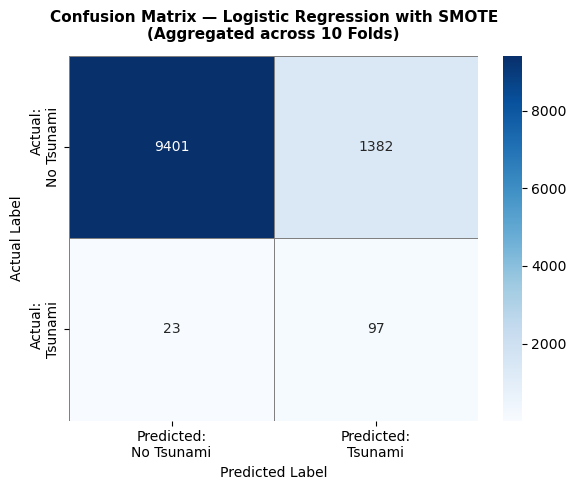

Saved: fig4_confusion_matrix.png


In [263]:
# =========================================
# Confusion Matrix — Logistic Regression with SMOTE
# Using saved X_main and y_main (120 tsunami positives)
# =========================================

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

print("Using y_main distribution:")
print(y_main.value_counts())

X_numeric = X_main.select_dtypes(include=['float64', 'int64'])

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

all_y_true = []
all_y_pred = []

for train_idx, test_idx in skf.split(X_numeric, y_main):
    X_train, X_test = X_numeric.iloc[train_idx], X_numeric.iloc[test_idx]
    y_train, y_test = y_main.iloc[train_idx], y_main.iloc[test_idx]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp  = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_test_sc  = scaler.transform(X_test_imp)

    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train_sc, y_train)

    model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    model.fit(X_res, y_res)

    y_pred = model.predict(X_test_sc)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

cm = confusion_matrix(all_y_true, all_y_pred)

print(f"\nTN: {cm[0][0]}  FP: {cm[0][1]}")
print(f"FN: {cm[1][0]}  TP: {cm[1][1]}")
print(f"Total Tsunami: {cm[1][0] + cm[1][1]}")
print(f"Recall: {cm[1][1] / (cm[1][0] + cm[1][1]):.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted:\nNo Tsunami', 'Predicted:\nTsunami'],
            yticklabels=['Actual:\nNo Tsunami', 'Actual:\nTsunami'],
            linewidths=0.5, linecolor='gray', ax=ax)

ax.set_title('Confusion Matrix — Logistic Regression with SMOTE\n(Aggregated across 10 Folds)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_ylabel('Actual Label', fontsize=10)
ax.set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.savefig('fig4_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig4_confusion_matrix.png")

### Final Model Selection

Two strong candidates emerged:

• Logistic Regression:
  - Highest recall (~80%)
  - Best for safety-critical applications

• Random Forest:
  - Best F1-score
  - Balanced precision and recall

Conclusion:

• Logistic Regression is preferred for early warning systems  
• Random Forest is suitable for balanced prediction scenarios

In [171]:
thresholds = [0.5, 0.3, 0.2, 0.1, 0.05]

print("Final Threshold Tuning (Logistic Regression)")

for t in thresholds:
    y_pred = (np.array(all_probs_lr) >= t).astype(int)

    print(f"\nThreshold = {t}")
    print("Precision:", precision_score(all_true_lr, y_pred))
    print("Recall   :", recall_score(all_true_lr, y_pred))
    print("F1       :", f1_score(all_true_lr, y_pred))

Final Threshold Tuning (Logistic Regression)

Threshold = 0.5
Precision: 0.06418918918918919
Recall   : 0.7983193277310925
F1       : 0.11882426516572858

Threshold = 0.3
Precision: 0.03789551140544518
Recall   : 0.865546218487395
F1       : 0.07261191399365527

Threshold = 0.2
Precision: 0.02791169753869576
Recall   : 0.9243697478991597
F1       : 0.054187192118226604

Threshold = 0.1
Precision: 0.0183735420993769
Recall   : 0.9663865546218487
F1       : 0.03606146127312637

Threshold = 0.05
Precision: 0.014383137011779294
Recall   : 0.9747899159663865
F1       : 0.028347996089931573


### Threshold Optimization

Default threshold (0.5) does not perform well for rare event detection.

Lower thresholds (e.g., 0.05):

• Increase recall significantly  
• Improve detection of tsunami events  
• Increase false positives  

Conclusion:

Lower thresholds are more suitable for early warning systems,
where missing an event is more critical than false alarms.

 ## Graph 1 — Recall Comparison (Without SMOTE vs With SMOTE)

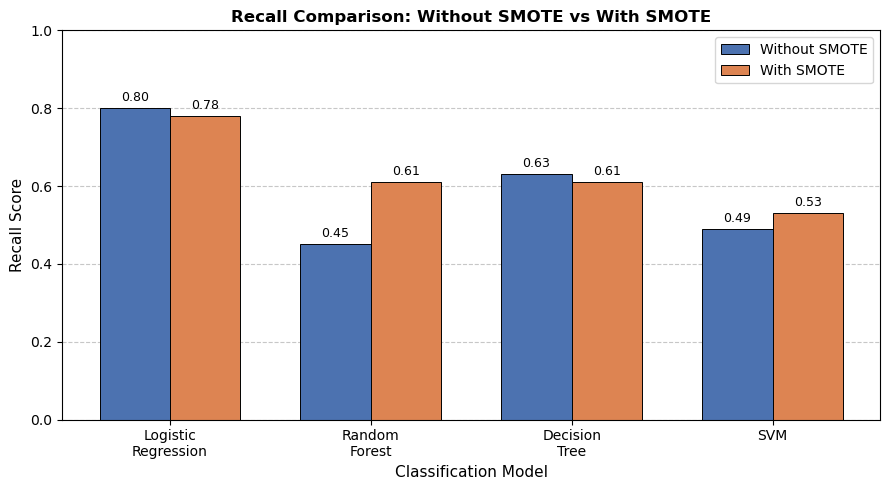

Graph 1 saved successfully


In [175]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your experiments
models = ['Logistic\nRegression', 'Random\nForest', 'Decision\nTree', 'SVM']

recall_no_smote = [0.80, 0.45, 0.63, 0.49]
recall_smote    = [0.78, 0.61, 0.61, 0.53]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, recall_no_smote, width,
               label='Without SMOTE', color='#4C72B0', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, recall_smote, width,
               label='With SMOTE', color='#DD8452', edgecolor='black', linewidth=0.7)

# Value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Classification Model', fontsize=11)
ax.set_ylabel('Recall Score', fontsize=11)
ax.set_title('Recall Comparison: Without SMOTE vs With SMOTE', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('graph1_recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graph 1 saved successfully")

## Graph 2 — ROC-AUC Comparison (Without SMOTE vs With SMOTE)

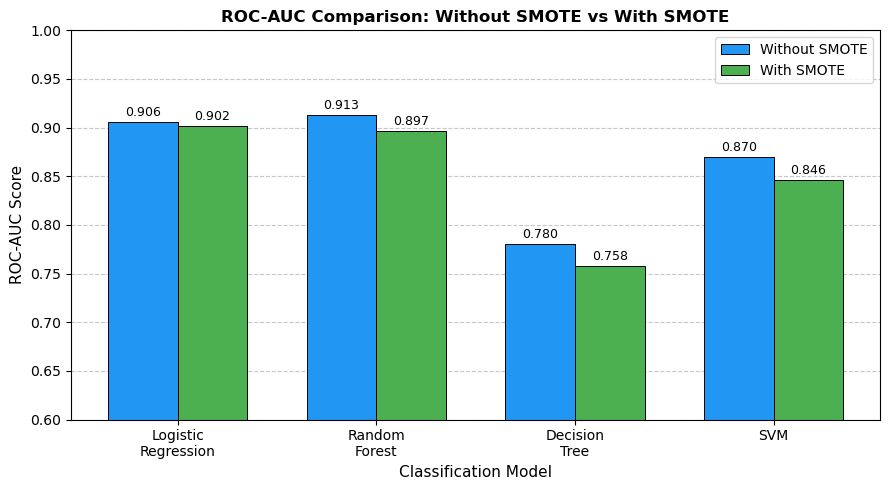

Graph 2 saved successfully


In [178]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic\nRegression', 'Random\nForest', 'Decision\nTree', 'SVM']

roc_no_smote = [0.906, 0.913, 0.780, 0.870]
roc_smote    = [0.902, 0.897, 0.758, 0.846]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, roc_no_smote, width,
               label='Without SMOTE', color='#2196F3', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, roc_smote, width,
               label='With SMOTE', color='#4CAF50', edgecolor='black', linewidth=0.7)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Classification Model', fontsize=11)
ax.set_ylabel('ROC-AUC Score', fontsize=11)
ax.set_title('ROC-AUC Comparison: Without SMOTE vs With SMOTE', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0.60, 1.0)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('graph2_roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graph 2 saved successfully")

## Graph 3 — All Metrics Comparison (With SMOTE)

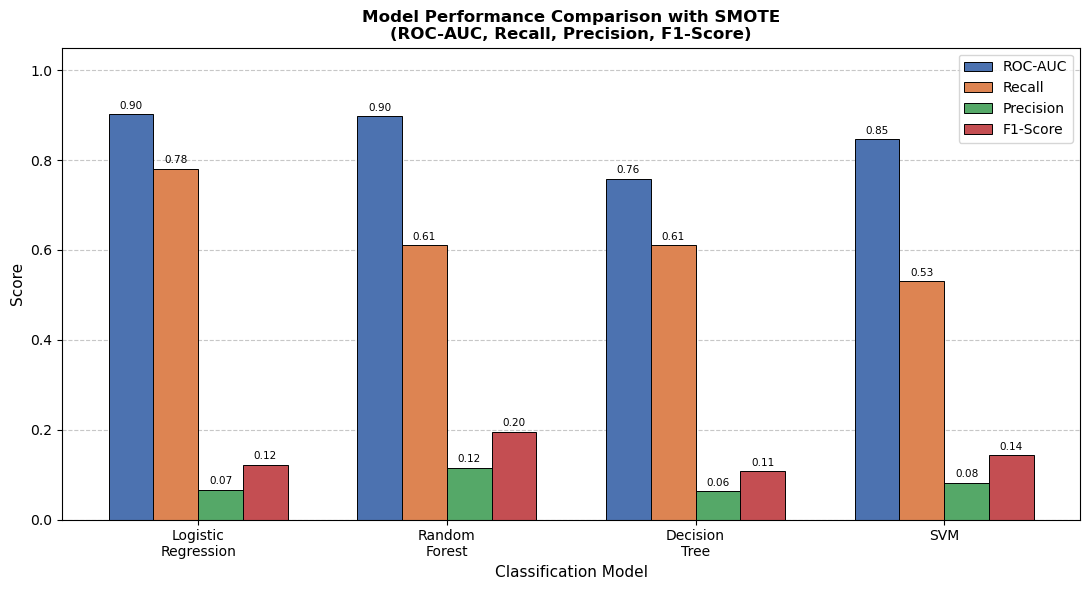

Graph 3 saved successfully


In [181]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic\nRegression', 'Random\nForest', 'Decision\nTree', 'SVM']

roc   = [0.902, 0.897, 0.758, 0.846]
recall    = [0.78,  0.61,  0.61,  0.53]
precision = [0.066, 0.115, 0.063, 0.082]
f1        = [0.122, 0.195, 0.107, 0.143]

x = np.arange(len(models))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 6))

b1 = ax.bar(x - 1.5*width, roc,       width, label='ROC-AUC',   color='#4C72B0', edgecolor='black', linewidth=0.7)
b2 = ax.bar(x - 0.5*width, recall,    width, label='Recall',     color='#DD8452', edgecolor='black', linewidth=0.7)
b3 = ax.bar(x + 0.5*width, precision, width, label='Precision',  color='#55A868', edgecolor='black', linewidth=0.7)
b4 = ax.bar(x + 1.5*width, f1,        width, label='F1-Score',   color='#C44E52', edgecolor='black', linewidth=0.7)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.008,
                f'{height:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Classification Model', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance Comparison with SMOTE\n(ROC-AUC, Recall, Precision, F1-Score)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('graph3_all_metrics_smote.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graph 3 saved successfully")

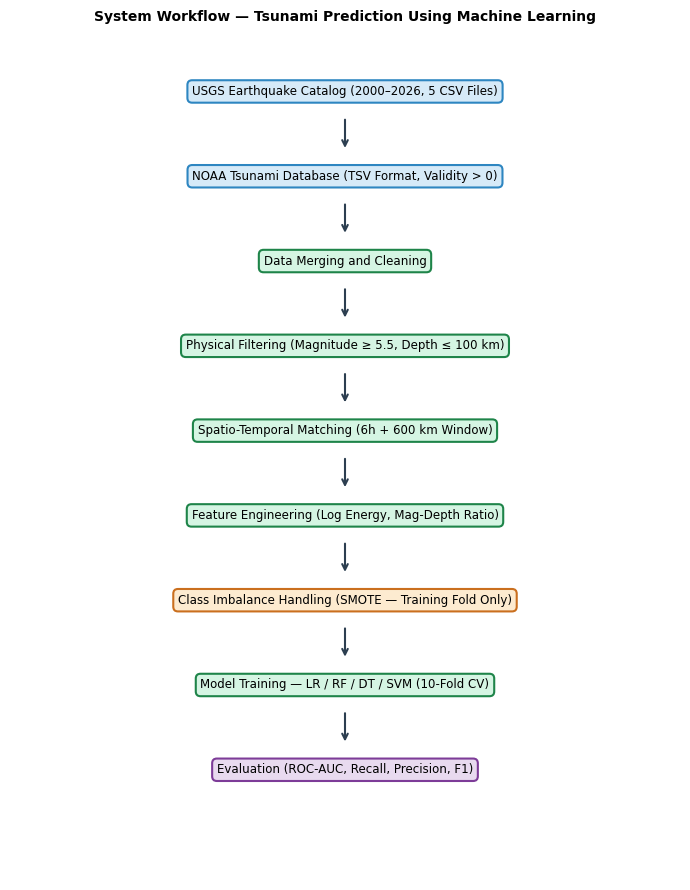

Saved: fig5_system_workflow.png


In [267]:
# =========================================
# System Workflow Diagram
# =========================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

box_style     = dict(boxstyle='round,pad=0.4', facecolor='#D6EAF8', edgecolor='#2E86C1', linewidth=1.5)
process_style = dict(boxstyle='round,pad=0.4', facecolor='#D5F5E3', edgecolor='#1E8449', linewidth=1.5)
decision_style= dict(boxstyle='round,pad=0.4', facecolor='#FDEBD0', edgecolor='#CA6F1E', linewidth=1.5)
final_style   = dict(boxstyle='round,pad=0.4', facecolor='#E8DAEF', edgecolor='#7D3C98', linewidth=1.5)

boxes = [
    (5, 9.3, 'USGS Earthquake Catalog (2000–2026, 5 CSV Files)',     box_style),
    (5, 8.3, 'NOAA Tsunami Database (TSV Format, Validity > 0)',      box_style),
    (5, 7.3, 'Data Merging and Cleaning',                            process_style),
    (5, 6.3, 'Physical Filtering (Magnitude ≥ 5.5, Depth ≤ 100 km)',process_style),
    (5, 5.3, 'Spatio-Temporal Matching (6h + 600 km Window)',        process_style),
    (5, 4.3, 'Feature Engineering (Log Energy, Mag-Depth Ratio)',    process_style),
    (5, 3.3, 'Class Imbalance Handling (SMOTE — Training Fold Only)',decision_style),
    (5, 2.3, 'Model Training — LR / RF / DT / SVM (10-Fold CV)',    process_style),
    (5, 1.3, 'Evaluation (ROC-AUC, Recall, Precision, F1)',         final_style),
]

for (x, y, text, style) in boxes:
    ax.text(x, y, text, ha='center', va='center', fontsize=8.5, bbox=style)

y_positions = [9.3, 8.3, 7.3, 6.3, 5.3, 4.3, 3.3, 2.3, 1.3]
for i in range(len(y_positions) - 1):
    ax.annotate('', xy=(5, y_positions[i+1] + 0.3),
                xytext=(5, y_positions[i] - 0.3),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))

ax.set_title('System Workflow — Tsunami Prediction Using Machine Learning',
             fontsize=10, fontweight='bold', pad=8)

plt.tight_layout()
plt.savefig('fig5_system_workflow.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig5_system_workflow.png")